In [6]:
import contextlib
import io
import warnings
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from IPython.display import HTML, display


def make_grid(n):
    """Create a uniform square grid on the unit square."""
    x = np.linspace(0.0, 1.0, n)
    y = np.linspace(0.0, 1.0, n)
    X, Y = np.meshgrid(x, y, indexing="ij")
    h = 1.0 / (n - 1)

    return x, y, X, Y, h


def make_true_conductivity(X, Y):
    """Construct the true conductivity used in the reconstruction."""
    gamma = np.ones_like(X)
    gamma += 0.9 * np.exp(
        -((X - 0.68) ** 2 + (Y - 0.36) ** 2) / 0.012
    )
    gamma -= 0.4 * np.exp(
        -((X - 0.32) ** 2 + (Y - 0.72) ** 2) / 0.020
    )

    return np.maximum(gamma, 0.2)


def interior_index_map(n):
    """Map interior grid points to indices in the linear system."""
    idx = -np.ones((n, n), dtype=int)
    k = 0

    for i in range(1, n - 1):
        for j in range(1, n - 1):
            idx[i, j] = k
            k += 1

    return idx, k


def build_system_matrix(gamma):
    """Build the sparse matrix for the conductivity equation."""
    n = gamma.shape[0]
    h = 1.0 / (n - 1)
    idx, N = interior_index_map(n)

    rows = []
    cols = []
    data = []

    def add_entry(row, col, value):
        rows.append(row)
        cols.append(col)
        data.append(value)

    for i in range(1, n - 1):
        for j in range(1, n - 1):
            p = idx[i, j]

            ge = 0.5 * (gamma[i, j] + gamma[i + 1, j])
            gw = 0.5 * (gamma[i, j] + gamma[i - 1, j])
            gn = 0.5 * (gamma[i, j] + gamma[i, j + 1])
            gs = 0.5 * (gamma[i, j] + gamma[i, j - 1])

            diagonal = (ge + gw + gn + gs) / h**2
            add_entry(p, p, diagonal)

            if i + 1 <= n - 2:
                add_entry(p, idx[i + 1, j], -ge / h**2)
            if i - 1 >= 1:
                add_entry(p, idx[i - 1, j], -gw / h**2)
            if j + 1 <= n - 2:
                add_entry(p, idx[i, j + 1], -gn / h**2)
            if j - 1 >= 1:
                add_entry(p, idx[i, j - 1], -gs / h**2)

    A = sp.csr_matrix(
        (data, (rows, cols)),
        shape=(N, N),
    )

    return A


def solve_conductivity(gamma, bc, rhs=None):
    """Solve the conductivity equation with Dirichlet boundary data.

    The discrete problem approximates

        -div(gamma grad u) = rhs    in Omega,
        u = bc                     on the boundary.
    """
    n = gamma.shape[0]
    h = 1.0 / (n - 1)
    idx, N = interior_index_map(n)

    if rhs is None:
        rhs = np.zeros_like(gamma)

    A = build_system_matrix(gamma)
    b = np.zeros(N)

    for i in range(1, n - 1):
        for j in range(1, n - 1):
            p = idx[i, j]

            ge = 0.5 * (gamma[i, j] + gamma[i + 1, j])
            gw = 0.5 * (gamma[i, j] + gamma[i - 1, j])
            gn = 0.5 * (gamma[i, j] + gamma[i, j + 1])
            gs = 0.5 * (gamma[i, j] + gamma[i, j - 1])

            if i + 1 == n - 1:
                b[p] += ge * bc[i + 1, j] / h**2
            if i - 1 == 0:
                b[p] += gw * bc[i - 1, j] / h**2
            if j + 1 == n - 1:
                b[p] += gn * bc[i, j + 1] / h**2
            if j - 1 == 0:
                b[p] += gs * bc[i, j - 1] / h**2

            b[p] += rhs[i, j]

    u_interior = spla.spsolve(A, b)

    u = np.array(bc, copy=True)

    for i in range(1, n - 1):
        for j in range(1, n - 1):
            u[i, j] = u_interior[idx[i, j]]

    return u


def gradients(u, h):
    """Approximate the spatial derivatives of a grid function."""
    ux = np.zeros_like(u)
    uy = np.zeros_like(u)

    ux[1:-1, :] = (u[2:, :] - u[:-2, :]) / (2.0 * h)
    uy[:, 1:-1] = (u[:, 2:] - u[:, :-2]) / (2.0 * h)

    ux[0, :] = (u[1, :] - u[0, :]) / h
    ux[-1, :] = (u[-1, :] - u[-2, :]) / h
    uy[:, 0] = (u[:, 1] - u[:, 0]) / h
    uy[:, -1] = (u[:, -1] - u[:, -2]) / h

    return ux, uy


def boundary_flux(gamma, u, h):
    """Approximate the outward conductivity flux on each boundary."""
    return {
        "left": gamma[0, :] * (u[0, :] - u[1, :]) / h,
        "right": gamma[-1, :] * (u[-1, :] - u[-2, :]) / h,
        "bottom": gamma[:, 0] * (u[:, 0] - u[:, 1]) / h,
        "top": gamma[:, -1] * (u[:, -1] - u[:, -2]) / h,
    }


def boundary_values_from_bc(g):
    """Extract boundary values from a grid function."""
    return {
        "left": g[0, :].copy(),
        "right": g[-1, :].copy(),
        "bottom": g[:, 0].copy(),
        "top": g[:, -1].copy(),
    }


def boundary_inner_product(a, b, h):
    """Approximate the boundary integral of a times b.

    Corner values are counted twice, which is retained from the
    original discretization.
    """
    total = 0.0

    for side in ("left", "right", "bottom", "top"):
        total += np.sum(a[side] * b[side]) * h

    return total


def reconstruct_from_basis(coeffs, basis):
    """Reconstruct a conductivity update from its basis coefficients."""
    reconstruction = np.zeros_like(basis[0])

    for coefficient, basis_function in zip(coeffs, basis):
        reconstruction += coefficient * basis_function

    return reconstruction


def build_projected_system(
    gamma_k,
    forward_inputs,
    test_functions,
    q_meas_list,
    basis,
):
    """Build the projected linearized system A c approximately equal r.

    The system is formed from

        sum_j c_j integral_Omega psi_j
            (grad u_{k,m} . grad v_{k,ell}) dx

        approximately equal

        integral_boundary g_ell
            (q_m^meas - q_{k,m}) ds.

    Here v_{k,ell} solves the harmonic test problem with boundary
    data g_ell.
    """
    n = gamma_k.shape[0]
    h = 1.0 / (n - 1)

    u_list = []
    q_pred_list = []

    for f_bc in forward_inputs:
        u = solve_conductivity(gamma_k, f_bc)
        q = boundary_flux(gamma_k, u, h)

        u_list.append(u)
        q_pred_list.append(q)

    v_list = []

    for g_bc in test_functions:
        v = solve_conductivity(gamma_k, g_bc)
        v_list.append(v)

    M = len(forward_inputs)
    L = len(test_functions)
    J = len(basis)

    A = np.zeros((M * L, J))
    r = np.zeros(M * L)

    row = 0

    for m in range(M):
        u = u_list[m]
        ux, uy = gradients(u, h)

        q_res = {
            side: q_meas_list[m][side] - q_pred_list[m][side]
            for side in q_pred_list[m]
        }

        for ell in range(L):
            g_bc = test_functions[ell]
            g_bnd = boundary_values_from_bc(g_bc)

            v = v_list[ell]
            vx, vy = gradients(v, h)

            gradient_product = ux * vx + uy * vy

            r[row] = boundary_inner_product(g_bnd, q_res, h)

            for j, psi_j in enumerate(basis):
                integrand = (
                    psi_j[1:-1, 1:-1]
                    * gradient_product[1:-1, 1:-1]
                )
                A[row, j] = np.sum(integrand) * h**2

            row += 1

    return A, r, u_list, v_list, q_pred_list


def make_boundary_field(n, side_values):
    """Create a grid containing prescribed boundary values."""
    bc = np.zeros((n, n))

    if "left" in side_values:
        bc[0, :] = side_values["left"]
    if "right" in side_values:
        bc[-1, :] = side_values["right"]
    if "bottom" in side_values:
        bc[:, 0] = side_values["bottom"]
    if "top" in side_values:
        bc[:, -1] = side_values["top"]

    return bc


def make_forward_inputs(n, x, y):
    """Construct the boundary inputs f_m for the forward problems."""
    inputs = [
        make_boundary_field(
            n,
            {"left": np.sin(np.pi * y)},
        ),
        make_boundary_field(
            n,
            {"right": np.sin(np.pi * y)},
        ),
        make_boundary_field(
            n,
            {"bottom": np.sin(np.pi * x)},
        ),
        make_boundary_field(
            n,
            {"top": np.sin(np.pi * x)},
        ),
        make_boundary_field(
            n,
            {"left": np.sin(2.0 * np.pi * y)},
        ),
        make_boundary_field(
            n,
            {"bottom": np.sin(2.0 * np.pi * x)},
        ),
        make_boundary_field(
            n,
            {
                "left": y * (1.0 - y),
                "right": -y * (1.0 - y),
            },
        ),
        make_boundary_field(
            n,
            {
                "bottom": x * (1.0 - x),
                "top": -x * (1.0 - x),
            },
        ),
    ]

    return inputs


def make_test_boundary_functions(n, x, y):
    """Construct the boundary data g_ell for the test problems."""
    tests = [
        make_boundary_field(
            n,
            {"left": np.sin(np.pi * y)},
        ),
        make_boundary_field(
            n,
            {"right": np.sin(np.pi * y)},
        ),
        make_boundary_field(
            n,
            {"bottom": np.sin(np.pi * x)},
        ),
        make_boundary_field(
            n,
            {"top": np.sin(np.pi * x)},
        ),
        make_boundary_field(
            n,
            {
                "left": y * (1.0 - y),
                "right": -y * (1.0 - y),
            },
        ),
        make_boundary_field(
            n,
            {
                "bottom": x * (1.0 - x),
                "top": -x * (1.0 - x),
            },
        ),
    ]

    return tests


def simulate_measured_fluxes(
    gamma_true,
    forward_inputs,
    noise_level=0.0,
    seed=0,
):
    """Generate noisy boundary-flux measurements."""
    rng = np.random.default_rng(seed)
    h = 1.0 / (gamma_true.shape[0] - 1)

    q_meas_list = []

    for f_bc in forward_inputs:
        u_true = solve_conductivity(gamma_true, f_bc)
        q_true = boundary_flux(gamma_true, u_true, h)

        if noise_level > 0:
            q_noisy = {}

            for side, values in q_true.items():
                sigma = (
                    noise_level
                    * np.linalg.norm(values)
                    / np.sqrt(values.size)
                )
                q_noisy[side] = (
                    values
                    + sigma * rng.standard_normal(values.shape)
                )

            q_meas_list.append(q_noisy)
        else:
            q_meas_list.append(q_true)

    return q_meas_list


def gaussian_basis(X, Y, centers_x, centers_y, sigma):
    """Construct Gaussian basis functions on the grid."""
    basis = []

    for cx in centers_x:
        for cy in centers_y:
            exponent = (
                -((X - cx) ** 2 + (Y - cy) ** 2)
                / (2.0 * sigma**2)
            )
            basis.append(np.exp(exponent))

    return basis


if __name__ == "__main__":
    np.random.seed(0)

    n = 61
    x, y, X, Y, h = make_grid(n)

    gamma_true = make_true_conductivity(X, Y)
    gamma0 = np.ones((n, n))

    forward_inputs = make_forward_inputs(n, x, y)
    test_functions = make_test_boundary_functions(n, x, y)

    q_meas_list = simulate_measured_fluxes(
        gamma_true,
        forward_inputs,
        noise_level=0.01,
        seed=1,
    )

    centers_x = np.linspace(0.15, 0.85, 5)
    centers_y = np.linspace(0.15, 0.85, 5)

    basis = gaussian_basis(
        X,
        Y,
        centers_x,
        centers_y,
        sigma=0.14,
    )

In [2]:
def solve_projected_Tikhonov(A, r, alpha):
    """Solve the projected system using Classical Tikhonov regularization.

    The method minimizes

        ||Ac - r||^2 + alpha ||c||^2,

    which gives the linear system

        (A^T A + alpha I)c = A^T r.
    """
    J = A.shape[1]
    lhs = A.T @ A + alpha * np.eye(J)
    rhs = A.T @ r
    c = np.linalg.solve(lhs, rhs)

    info = {
        "method": "classic_Tikhonov",
        "alpha": alpha,
        "res_norm": np.linalg.norm(A @ c - r),
        "c_norm": np.linalg.norm(c),
    }

    return c, info


def solve_projected_at(
    A,
    r,
    mu=1e-2,
    delta=0.0,
    tol=1e-10,
    max_iter=100,
    svd_tol=1e-12,
):
    """Solve the projected system using Alternate Tikhonov.

    The method solves directly for lambda satisfying

        ||A c_lambda - r|| = delta + mu ||c_lambda||,

    where

        c_lambda =
            lambda (I + lambda A^T A)^(-1) A^T r.

    Newton's method is used inside a bracket, with bisection used
    whenever the Newton step leaves the bracket.
    """
    A = np.asarray(A, dtype=float)
    r = np.asarray(r, dtype=float)

    if mu < 0:
        raise ValueError("mu must be nonnegative.")
    if delta < 0:
        raise ValueError("delta must be nonnegative.")

    U, s, Vt = np.linalg.svd(A, full_matrices=False)

    beta = U.T @ r
    r_norm = float(np.linalg.norm(r))

    if len(s) > 0:
        cutoff = svd_tol * max(A.shape) * s[0]
    else:
        cutoff = svd_tol

    pos = s > cutoff

    outside_sq = max(
        0.0,
        r_norm**2 - float(np.sum(beta**2)),
    )
    zero_singular_sq = float(np.sum(beta[~pos] ** 2))

    sp = s[pos]
    bp = beta[pos]

    sig2 = sp**2
    beta2 = bp**2

    def eval_lambda(lam, need_c=False):
        if lam == 0:
            c = np.zeros(A.shape[1]) if need_c else None
            return c, r_norm, 0.0, None

        denom = 1.0 + lam * sig2
        coeff_pos = (lam * sp / denom) * bp

        res_sq = outside_sq + zero_singular_sq
        res_sq += float(np.sum((bp / denom) ** 2))
        res_norm = float(np.sqrt(max(0.0, res_sq)))

        c_norm_sq = float(np.sum(coeff_pos**2))
        c_norm = float(np.sqrt(max(0.0, c_norm_sq)))

        common = float(
            np.sum(beta2 * sig2 / (denom**3))
        )

        if res_norm > 0:
            res_prime = -common / res_norm
        else:
            res_prime = 0.0

        if c_norm > 0:
            c_norm_prime = lam * common / c_norm
        else:
            c_norm_prime = 0.0

        H_prime = res_prime - mu * c_norm_prime

        c = None
        if need_c:
            coeff = np.zeros_like(s)
            coeff[pos] = coeff_pos
            c = Vt.T @ coeff

        return c, res_norm, c_norm, H_prime

    def H(lam):
        _, res_norm, c_norm, _ = eval_lambda(
            lam,
            need_c=False,
        )
        return res_norm - delta - mu * c_norm

    history = []
    H0 = H(0.0)

    if H0 <= 0:
        c = np.zeros(A.shape[1])

        info = {
            "method": "improved_tt_direct_lambda",
            "mu": mu,
            "delta": delta,
            "lambda_star": 0.0,
            "rho_star": r_norm,
            "res_norm": r_norm,
            "c_norm": 0.0,
            "tt_condition_error": (
                r_norm - (delta + mu * 0.0)
            ),
            "iterations": 0,
            "converged": True,
            "message": (
                "c=0 is feasible because ||r|| <= delta."
            ),
            "history": history,
        }

        return c, info

    lam_low = 0.0
    H_low = H0

    lam_high = 1.0
    H_high = H(lam_high)

    bracket_iter = 0

    while H_high > 0:
        lam_high = lam_high * 2
        H_high = H(lam_high)

        history.append(
            {
                "phase": "bracket",
                "iter": bracket_iter,
                "lambda_low": lam_low,
                "lambda_high": lam_high,
                "H_low": H_low,
                "H_high": H_high,
            }
        )

        if lam_high > 1e200:
            coeff = np.zeros_like(s)
            coeff[pos] = bp / sp
            c = Vt.T @ coeff

            res_norm = np.linalg.norm(A @ c - r)
            c_norm = np.linalg.norm(c)

            info = {
                "method": "improved_tt_direct_lambda",
                "mu": mu,
                "delta": delta,
                "lambda_star": np.inf,
                "rho_star": res_norm,
                "res_norm": res_norm,
                "c_norm": c_norm,
                "tt_condition_error": (
                    res_norm - (delta + mu * c_norm)
                ),
                "iterations": bracket_iter,
                "converged": False,
                "message": (
                    "No finite lambda root was bracketed; "
                    "returned minimum-residual solution."
                ),
                "history": history,
            }

            return c, info

    lam = 0.5 * (lam_low + lam_high)
    converged = False

    for it in range(max_iter):
        _, res_norm, c_norm, H_prime = eval_lambda(
            lam,
            need_c=False,
        )
        H_lam = res_norm - delta - mu * c_norm

        history.append(
            {
                "phase": "solve",
                "iter": it,
                "lambda": lam,
                "H": H_lam,
                "res_norm": res_norm,
                "c_norm": c_norm,
                "target": delta + mu * c_norm,
                "lambda_low": lam_low,
                "lambda_high": lam_high,
            }
        )

        if abs(H_lam) <= tol * max(
            1.0,
            delta + mu * c_norm,
        ):
            converged = True
            break

        if H_lam > 0:
            lam_low = lam
            H_low = H_lam
        else:
            lam_high = lam
            H_high = H_lam

        if (
            H_prime is not None
            and H_prime < 0
            and np.isfinite(H_prime)
        ):
            lam_new = lam - H_lam / H_prime
        else:
            lam_new = np.nan

        if (
            not np.isfinite(lam_new)
            or not (lam_low < lam_new < lam_high)
        ):
            lam_new = 0.5 * (lam_low + lam_high)

        if abs(lam_high - lam_low) <= tol * max(
            1.0,
            abs(lam_new),
        ):
            lam = lam_new
            converged = True
            break

        lam = lam_new

    c, res_norm, c_norm, _ = eval_lambda(
        lam,
        need_c=True,
    )

    info = {
        "method": "improved_tt_direct_lambda",
        "mu": mu,
        "delta": delta,
        "lambda_star": lam,
        "rho_star": res_norm,
        "res_norm": res_norm,
        "c_norm": c_norm,
        "tt_condition_error": (
            res_norm - (delta + mu * c_norm)
        ),
        "iterations": it + 1,
        "converged": converged,
        "message": (
            "Solved ||Ac-r|| = delta + mu||c|| directly."
        ),
        "history": history,
    }

    return c, info


def one_step_identity_update(
    gamma_k,
    forward_inputs,
    test_functions,
    q_meas_list,
    basis,
    method="CT",
    alpha=1e-3,
    mu=1e-2,
    delta=0.0,
    damping=1.0,
    positivity_floor=1e-3,
):
    """Perform one identity-based conductivity reconstruction step."""
    A, r, u_list, v_list, q_pred_list = (
        build_projected_system(
            gamma_k,
            forward_inputs,
            test_functions,
            q_meas_list,
            basis,
        )
    )

    if method == "CT":
        c, reg_info = solve_projected_Tikhonov(
            A,
            r,
            alpha,
        )
    elif method == "AT":
        c, reg_info = solve_projected_at(
            A,
            r,
            mu=mu,
            delta=delta,
        )
    else:
        raise ValueError(
            "method must be either 'CT' or 'AT'."
        )

    delta_gamma = reconstruct_from_basis(c, basis)

    gamma_next = np.maximum(
        gamma_k + damping * delta_gamma,
        positivity_floor,
    )

    info = {
        "A": A,
        "r": r,
        "coeffs": c,
        "delta_gamma": delta_gamma,
        "u_list": u_list,
        "v_list": v_list,
        "q_pred_list": q_pred_list,
        "system_residual_norm": np.linalg.norm(A @ c - r),
        "coeff_norm": np.linalg.norm(c),
        "reg_info": reg_info,
        "method": method,
    }

    return gamma_next, info


def run_identity_iteration(
    gamma0,
    forward_inputs,
    test_functions,
    q_meas_list,
    basis,
    n_iters=10,
    method="CT",
    alpha=1e-3,
    mu=1e-2,
    delta=1e-3,
    damping=1.0,
    positivity_floor=1e-3,
    gamma_true=None,
):
    """Run the identity-based conductivity reconstruction."""
    gamma = gamma0.copy()
    history = []

    for k in range(n_iters):
        gamma_next, info = one_step_identity_update(
            gamma,
            forward_inputs,
            test_functions,
            q_meas_list,
            basis,
            method=method,
            alpha=alpha,
            mu=mu,
            delta=delta,
            damping=damping,
            positivity_floor=positivity_floor,
        )

        step_norm = np.linalg.norm(gamma_next - gamma)

        hist_item = {
            "iter": k,
            "method": method,
            "projected_system_residual_norm": (
                info["system_residual_norm"]
            ),
            "coeff_norm": info["coeff_norm"],
            "step_norm": step_norm,
        }

        if gamma_true is not None:
            reconstruction_error = np.linalg.norm(
                gamma_next - gamma_true
            )
            hist_item["reconstruction_error_norm"] = (
                reconstruction_error
            )
            hist_item["relative_reconstruction_error"] = (
                reconstruction_error
                / max(
                    1e-16,
                    np.linalg.norm(gamma_true),
                )
            )

        if method == "AT":
            hist_item["rho_star"] = (
                info["reg_info"]["rho_star"]
            )
            hist_item["lambda_star"] = (
                info["reg_info"]["lambda_star"]
            )
            hist_item["tt_condition_error"] = (
                info["reg_info"]["tt_condition_error"]
            )
            hist_item["tt_converged"] = (
                info["reg_info"]["converged"]
            )

        history.append(hist_item)

        if method == "CT":
            print(
                f"[CT] iter={k:02d} | "
                f"proj_res="
                f"{info['system_residual_norm']:.4e} | "
                f"coeff_norm={info['coeff_norm']:.4e} | "
                f"step_norm={step_norm:.4e}"
            )

        elif method == "AT":
            print(
                f"[AT] iter={k:02d} | "
                f"proj_res="
                f"{info['system_residual_norm']:.4e} | "
                f"coeff_norm={info['coeff_norm']:.4e} | "
                f"rho*={info['reg_info']['rho_star']:.4e} | "
                f"lambda*="
                f"{info['reg_info']['lambda_star']:.4e} | "
                f"Alternate Tikhonov error="
                f"{info['reg_info']['tt_condition_error']:.4e} | "
                f"step_norm={step_norm:.4e}"
            )

        gamma = gamma_next

    return gamma, history

In [3]:
# Sweep reconstruction parameters and export the results to Excel.

n_iter_values = [3, 4, 5, 10, 20, 30]
omega_values = [0.5, 0.8, 1.0]

alpha_values = [
    1e-5,
    3e-5,
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2,
]

mu_values = [
    1e-3,
    3e-3,
    1e-2,
    3e-2,
    1e-1,
    3e-1,
]

delta_values = [
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2,
]

positivity_floor = 1e-3


def relative_reconstruction_error(gamma_rec, gamma_true):
    """Return the relative error of a reconstructed conductivity."""
    numerator = np.linalg.norm(gamma_rec - gamma_true)
    denominator = max(1e-16, np.linalg.norm(gamma_true))

    return numerator / denominator


def run_one_case(
    method,
    n_iters,
    omega,
    alpha=None,
    mu=None,
    delta=None,
):
    """Run one reconstruction and return its parameter information."""
    result = {
        "method": method,
        "n_iters": n_iters,
        "omega": omega,
        "alpha": alpha,
        "mu": mu,
        "delta": delta,
        "relative_error": np.inf,
        "success": False,
    }

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            with contextlib.redirect_stdout(io.StringIO()):
                if method == "CT":
                    gamma_rec, _ = run_identity_iteration(
                        gamma0=gamma0,
                        forward_inputs=forward_inputs,
                        test_functions=test_functions,
                        q_meas_list=q_meas_list,
                        basis=basis,
                        n_iters=n_iters,
                        method="CT",
                        alpha=alpha,
                        damping=omega,
                        positivity_floor=positivity_floor,
                        gamma_true=gamma_true,
                    )

                elif method == "AT":
                    gamma_rec, _ = run_identity_iteration(
                        gamma0=gamma0,
                        forward_inputs=forward_inputs,
                        test_functions=test_functions,
                        q_meas_list=q_meas_list,
                        basis=basis,
                        n_iters=n_iters,
                        method="AT",
                        mu=mu,
                        delta=delta,
                        damping=omega,
                        positivity_floor=positivity_floor,
                        gamma_true=gamma_true,
                    )

                else:
                    raise ValueError(
                        "method must be either 'CT' or 'AT'."
                    )

        error = relative_reconstruction_error(
            gamma_rec,
            gamma_true,
        )

        if (
            not np.isfinite(error)
            or not np.all(np.isfinite(gamma_rec))
        ):
            raise FloatingPointError(
                "Non-finite reconstruction or error."
            )

        result["relative_error"] = error
        result["success"] = True

    except Exception:
        result["success"] = False

    return result


records = []

total_CT = (
    len(n_iter_values)
    * len(omega_values)
    * len(alpha_values)
)

total_AT = (
    len(n_iter_values)
    * len(omega_values)
    * len(mu_values)
    * len(delta_values)
)

total_runs = total_CT + total_AT

print(f"Total Classical Tikhonov runs: {total_CT}")
print(f"Total Alternate Tikhonov runs: {total_AT}")
print(f"Total runs: {total_runs}")

run_counter = 0

for n_iters, omega, alpha in product(
    n_iter_values,
    omega_values,
    alpha_values,
):
    run_counter += 1

    print(
        f"[{run_counter:03d}/{total_runs}] "
        f"Classical Tikhonov | "
        f"iterations={n_iters}, "
        f"omega={omega}, "
        f"alpha={alpha:.1e}"
    )

    record = run_one_case(
        method="CT",
        n_iters=n_iters,
        omega=omega,
        alpha=alpha,
    )

    record["run"] = run_counter
    records.append(record)


for n_iters, omega, mu, delta in product(
    n_iter_values,
    omega_values,
    mu_values,
    delta_values,
):
    run_counter += 1

    print(
        f"[{run_counter:03d}/{total_runs}] "
        f"Alternate Tikhonov | "
        f"iterations={n_iters}, "
        f"omega={omega}, "
        f"mu={mu:.1e}, "
        f"delta={delta:.1e}"
    )

    record = run_one_case(
        method="AT",
        n_iters=n_iters,
        omega=omega,
        mu=mu,
        delta=delta,
    )

    record["run"] = run_counter
    records.append(record)


def method_name(method):
    """Return the full name of a regularization method."""
    if method == "CT":
        return "Classical Tikhonov"

    if method == "AT":
        return "Alternate Tikhonov"

    return str(method)


def sci_plain(value):
    """Format a number in scientific notation."""
    if value is None or pd.isna(value):
        return ""

    return f"{float(value):.0e}"


def damping_plain(record):
    """Format the damping parameter for output."""
    return f"omega = {float(record['omega']):g}"


def regularization_parameters_plain(record):
    """Format the regularization parameters for output."""
    if record["method"] == "CT":
        return f"alpha = {sci_plain(record.get('alpha'))}"

    if record["method"] == "AT":
        return (
            f"mu = {sci_plain(record.get('mu'))}; "
            f"delta = {sci_plain(record.get('delta'))}"
        )

    return ""


def clean_records(records):
    """Return successful records with finite relative errors."""
    good = []

    for record in records:
        if not record.get("success", False):
            continue

        if not np.isfinite(
            record.get("relative_error", np.inf)
        ):
            continue

        good.append(record)

    return good


good_records = clean_records(records)


def make_results_table(
    records,
    include_run=False,
    sort_by_error=True,
):
    """Convert reconstruction records to an output table."""
    rows = []

    for record in records:
        row = {}

        if include_run:
            row["Run"] = int(record["run"])

        row.update(
            {
                "Method": method_name(record["method"]),
                "Iterations": int(record["n_iters"]),
                "Damping": damping_plain(record),
                "Regularization parameters": (
                    regularization_parameters_plain(record)
                ),
                "Relative error": (
                    float(record["relative_error"])
                    if np.isfinite(record["relative_error"])
                    else np.nan
                ),
            }
        )

        rows.append(row)

    table = pd.DataFrame(rows)

    if sort_by_error and not table.empty:
        table = table.sort_values(
            "Relative error",
            na_position="last",
        )

    return table.reset_index(drop=True)


def best_by_parameter_records(records, method, parameter):
    """Return the best result for each value of a parameter."""
    method_records = [
        record
        for record in records
        if record["method"] == method
    ]

    values = sorted(
        {
            record.get(parameter)
            for record in method_records
            if (
                record.get(parameter) is not None
                and pd.notna(record.get(parameter))
            )
        }
    )

    best_records = []

    for value in values:
        matching_records = [
            record
            for record in method_records
            if record.get(parameter) == value
        ]

        if matching_records:
            best_records.append(
                min(
                    matching_records,
                    key=lambda record: record["relative_error"],
                )
            )

    return best_records


all_results_table = make_results_table(
    records,
    include_run=True,
    sort_by_error=False,
)

top_20_records = sorted(
    good_records,
    key=lambda record: record["relative_error"],
)[:20]

top_20_table = make_results_table(top_20_records)

excel_tables = {
    "All Results": all_results_table,
    "Top 20 Overall": top_20_table,
    "CT by Iteration": make_results_table(
        best_by_parameter_records(
            good_records,
            "CT",
            "n_iters",
        )
    ),
    "CT by Omega": make_results_table(
        best_by_parameter_records(
            good_records,
            "CT",
            "omega",
        )
    ),
    "CT by Alpha": make_results_table(
        best_by_parameter_records(
            good_records,
            "CT",
            "alpha",
        )
    ),
    "AT by Iteration": make_results_table(
        best_by_parameter_records(
            good_records,
            "AT",
            "n_iters",
        )
    ),
    "AT by Omega": make_results_table(
        best_by_parameter_records(
            good_records,
            "AT",
            "omega",
        )
    ),
    "AT by Mu": make_results_table(
        best_by_parameter_records(
            good_records,
            "AT",
            "mu",
        )
    ),
    "AT by Delta": make_results_table(
        best_by_parameter_records(
            good_records,
            "AT",
            "delta",
        )
    ),
}

excel_name = "parameter_sweep_results.xlsx"

with pd.ExcelWriter(
    excel_name,
    engine="openpyxl",
) as writer:
    for sheet_name, table in excel_tables.items():
        table.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False,
        )

display(FileLink(excel_name))

Total Classical Tikhonov runs: 126
Total Alternate Tikhonov runs: 540
Total runs: 666
[001/666] Classical Tikhonov | iterations=3, omega=0.5, alpha=1.0e-05
[002/666] Classical Tikhonov | iterations=3, omega=0.5, alpha=3.0e-05
[003/666] Classical Tikhonov | iterations=3, omega=0.5, alpha=1.0e-04
[004/666] Classical Tikhonov | iterations=3, omega=0.5, alpha=3.0e-04
[005/666] Classical Tikhonov | iterations=3, omega=0.5, alpha=1.0e-03
[006/666] Classical Tikhonov | iterations=3, omega=0.5, alpha=3.0e-03
[007/666] Classical Tikhonov | iterations=3, omega=0.5, alpha=1.0e-02
[008/666] Classical Tikhonov | iterations=3, omega=0.8, alpha=1.0e-05
[009/666] Classical Tikhonov | iterations=3, omega=0.8, alpha=3.0e-05
[010/666] Classical Tikhonov | iterations=3, omega=0.8, alpha=1.0e-04
[011/666] Classical Tikhonov | iterations=3, omega=0.8, alpha=3.0e-04
[012/666] Classical Tikhonov | iterations=3, omega=0.8, alpha=1.0e-03
[013/666] Classical Tikhonov | iterations=3, omega=0.8, alpha=3.0e-03
[014

C:\Users\Charlie\parameter_sweep_results.xlsx

Method,Iterations,Damping,Regularization parameters,Relative error
Alternate Tikhonov,3,ω = 0.8,μ = 1 × 10-2δ = 1 × 10-4,0.064730
Alternate Tikhonov,3,ω = 1,μ = 1 × 10-2δ = 3 × 10-4,0.064800
Alternate Tikhonov,4,ω = 0.8,μ = 1 × 10-2δ = 1 × 10-3,0.064905
Alternate Tikhonov,3,ω = 0.8,μ = 1 × 10-2δ = 3 × 10-4,0.065014
Alternate Tikhonov,3,ω = 1,μ = 1 × 10-2δ = 1 × 10-4,0.065128
Classical Tikhonov,3,ω = 1,α = 1 × 10-5,0.065173
Classical Tikhonov,5,ω = 0.8,α = 1 × 10-5,0.065182
Classical Tikhonov,4,ω = 1,α = 1 × 10-5,0.065183
Alternate Tikhonov,5,ω = 0.8,μ = 1 × 10-3δ = 3 × 10-3,0.065187
Alternate Tikhonov,5,ω = 0.5,μ = 1 × 10-2δ = 3 × 10-4,0.065193


Method,Iterations,Damping,Regularization parameters,Relative error
Alternate Tikhonov,3,ω = 0.8,μ = 1 × 10-2δ = 1 × 10-4,0.064730
Classical Tikhonov,3,ω = 1,α = 1 × 10-5,0.065173


Method,Iterations,Damping,Regularization parameters,Relative error
Classical Tikhonov,3,ω = 1,α = 1 × 10-5,0.065173
Classical Tikhonov,5,ω = 0.8,α = 1 × 10-5,0.065182
Classical Tikhonov,4,ω = 1,α = 1 × 10-5,0.065183
Classical Tikhonov,10,ω = 0.5,α = 1 × 10-5,0.065334
Classical Tikhonov,20,ω = 0.5,α = 3 × 10-5,0.065598
Classical Tikhonov,30,ω = 0.5,α = 3 × 10-5,0.065859


Method,Iterations,Damping,Regularization parameters,Relative error
Classical Tikhonov,3,ω = 1,α = 1 × 10-5,0.065173
Classical Tikhonov,5,ω = 0.8,α = 1 × 10-5,0.065182
Classical Tikhonov,10,ω = 0.5,α = 1 × 10-5,0.065334


Method,Iterations,Damping,Regularization parameters,Relative error
Classical Tikhonov,3,ω = 1,α = 1 × 10-5,0.065173
Classical Tikhonov,10,ω = 1,α = 3 × 10-5,0.065585
Classical Tikhonov,30,ω = 1,α = 1 × 10-4,0.065911
Classical Tikhonov,30,ω = 1,α = 3 × 10-4,0.067343
Classical Tikhonov,30,ω = 1,α = 1 × 10-3,0.069420
Classical Tikhonov,30,ω = 1,α = 3 × 10-3,0.072521
Classical Tikhonov,30,ω = 1,α = 1 × 10-2,0.076687


Method,Iterations,Damping,Regularization parameters,Relative error
Alternate Tikhonov,3,ω = 0.8,μ = 1 × 10-2δ = 1 × 10-4,0.064730
Alternate Tikhonov,4,ω = 0.8,μ = 1 × 10-2δ = 1 × 10-3,0.064905
Alternate Tikhonov,5,ω = 0.8,μ = 1 × 10-3δ = 3 × 10-3,0.065187
Alternate Tikhonov,20,ω = 0.5,μ = 3 × 10-2δ = 1 × 10-3,0.065618
Alternate Tikhonov,10,ω = 0.8,μ = 3 × 10-3δ = 3 × 10-3,0.065622
Alternate Tikhonov,30,ω = 0.8,μ = 1 × 10-1δ = 3 × 10-4,0.065876


Method,Iterations,Damping,Regularization parameters,Relative error
Alternate Tikhonov,3,ω = 0.8,μ = 1 × 10-2δ = 1 × 10-4,0.064730
Alternate Tikhonov,3,ω = 1,μ = 1 × 10-2δ = 3 × 10-4,0.064800
Alternate Tikhonov,5,ω = 0.5,μ = 1 × 10-2δ = 3 × 10-4,0.065193


Method,Iterations,Damping,Regularization parameters,Relative error
Alternate Tikhonov,3,ω = 0.8,μ = 1 × 10-2δ = 1 × 10-4,0.064730
Alternate Tikhonov,5,ω = 0.8,μ = 1 × 10-3δ = 3 × 10-3,0.065187
Alternate Tikhonov,20,ω = 0.5,μ = 3 × 10-2δ = 1 × 10-3,0.065618
Alternate Tikhonov,10,ω = 0.8,μ = 3 × 10-3δ = 3 × 10-3,0.065622
Alternate Tikhonov,30,ω = 0.8,μ = 1 × 10-1δ = 3 × 10-4,0.065876
Alternate Tikhonov,30,ω = 1,μ = 3 × 10-1δ = 1 × 10-4,0.071560


Method,Iterations,Damping,Regularization parameters,Relative error
Alternate Tikhonov,3,ω = 0.8,μ = 1 × 10-2δ = 1 × 10-4,0.064730
Alternate Tikhonov,3,ω = 1,μ = 1 × 10-2δ = 3 × 10-4,0.064800
Alternate Tikhonov,4,ω = 0.8,μ = 1 × 10-2δ = 1 × 10-3,0.064905
Alternate Tikhonov,5,ω = 0.8,μ = 1 × 10-3δ = 3 × 10-3,0.065187
Alternate Tikhonov,30,ω = 1,μ = 1 × 10-3δ = 1 × 10-2,0.090462


[CT] iter=00 | proj_res=2.9699e-03 | coeff_norm=5.1379e-01 | step_norm=6.1443e+00
[CT] iter=01 | proj_res=3.1665e-03 | coeff_norm=1.1781e-01 | step_norm=9.5998e-01
[CT] iter=02 | proj_res=3.2259e-03 | coeff_norm=6.8072e-02 | step_norm=3.6101e-01
[AT] iter=00 | proj_res=3.7798e-03 | coeff_norm=3.6798e-01 | rho*=3.7798e-03 | lambda*=6.5700e+03 | Alternate Tikhonov error=1.8818e-12 | step_norm=4.6058e+00
[AT] iter=01 | proj_res=3.0775e-03 | coeff_norm=2.9775e-01 | rho*=3.0775e-03 | lambda*=8.7663e+04 | Alternate Tikhonov error=8.6736e-17 | step_norm=1.7216e+00
[AT] iter=02 | proj_res=3.1234e-03 | coeff_norm=3.0234e-01 | rho*=3.1234e-03 | lambda*=5.6656e+05 | Alternate Tikhonov error=2.0470e-16 | step_norm=1.4000e+00


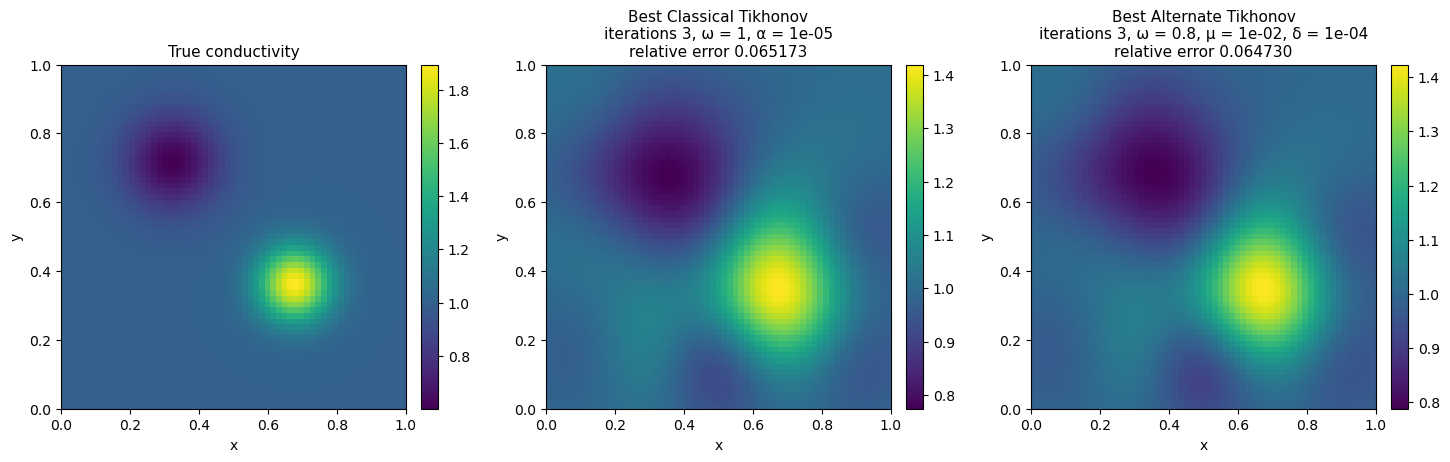

In [8]:
# Display summary tables and the best reconstruction from each method.

def method_name(method):
    """Return the full name of a regularization method."""
    if method == "CT":
        return "Classical Tikhonov"

    if method == "AT":
        return "Alternate Tikhonov"

    return str(method)


def sci_html(value):
    """Format a number in scientific notation for HTML output."""
    if value is None or pd.isna(value):
        return ""

    mantissa, exponent = f"{float(value):.0e}".split("e")
    exponent = int(exponent)

    return f"{mantissa} &times; 10<sup>{exponent}</sup>"


def sci_plain(value):
    """Format a number in scientific notation."""
    if value is None or pd.isna(value):
        return ""

    return f"{float(value):.0e}"


def damping_html(record):
    """Format the damping parameter for HTML output."""
    return f"&omega; = {float(record['omega']):g}"


def regularization_parameters_html(record):
    """Format the regularization parameters for HTML output."""
    if record["method"] == "CT":
        return (
            f"&alpha; = "
            f"{sci_html(record.get('alpha'))}"
        )

    if record["method"] == "AT":
        return (
            f"&mu; = {sci_html(record.get('mu'))}"
            f"<br>&delta; = {sci_html(record.get('delta'))}"
        )

    return ""


def clean_records(records):
    """Return successful records with finite relative errors."""
    good_records = []

    for record in records:
        if not record.get("success", False):
            continue

        if not np.isfinite(
            record.get("relative_error", np.inf)
        ):
            continue

        good_records.append(record)

    return good_records


good_records = clean_records(records)


def make_results_table(records):
    """Convert reconstruction records to a display table."""
    rows = []

    for record in records:
        rows.append(
            {
                "Method": method_name(record["method"]),
                "Iterations": int(record["n_iters"]),
                "Damping": damping_html(record),
                "Regularization parameters": (
                    regularization_parameters_html(record)
                ),
                "Relative error": (
                    f"{float(record['relative_error']):.6f}"
                ),
            }
        )

    table = pd.DataFrame(rows)

    if not table.empty:
        table["_sort_error"] = table[
            "Relative error"
        ].astype(float)

        table = (
            table.sort_values("_sort_error")
            .drop(columns="_sort_error")
        )

    return table.reset_index(drop=True)


def best_by_method_records(records):
    """Return the best result for each regularization method."""
    best_records = []

    for method in ("CT", "AT"):
        method_records = [
            record
            for record in records
            if record["method"] == method
        ]

        if method_records:
            best_records.append(
                min(
                    method_records,
                    key=lambda record: record["relative_error"],
                )
            )

    return sorted(
        best_records,
        key=lambda record: record["relative_error"],
    )


def best_by_parameter_records(records, method, parameter):
    """Return the best result for each value of a parameter."""
    method_records = [
        record
        for record in records
        if record["method"] == method
    ]

    values = sorted(
        {
            record.get(parameter)
            for record in method_records
            if (
                record.get(parameter) is not None
                and pd.notna(record.get(parameter))
            )
        }
    )

    best_records = []

    for value in values:
        matching_records = [
            record
            for record in method_records
            if record.get(parameter) == value
        ]

        if matching_records:
            best_records.append(
                min(
                    matching_records,
                    key=lambda record: record["relative_error"],
                )
            )

    return best_records


def display_clean_table(table, title):
    """Display a formatted results table in Jupyter."""
    if table.empty:
        html = f"""
        <div class="clean-sweep-title">{title}</div>
        <p style="font-family: Arial, sans-serif;">
            No successful runs to display.
        </p>
        """
        display(HTML(html))
        return

    table_html = table.to_html(
        index=False,
        escape=False,
        classes="clean-sweep-table",
    )

    html = f"""
    <style>
        .clean-sweep-title {{
            font-family: Arial, sans-serif;
            font-size: 25px;
            font-weight: 600;
            margin: 22px 0 12px 0;
        }}

        .clean-sweep-table {{
            border-collapse: collapse;
            font-family: Arial, sans-serif;
            font-size: 15px;
            min-width: 760px;
            margin-bottom: 28px;
        }}

        .clean-sweep-table th {{
            background-color: #f2f2f2;
            color: #111;
            font-weight: 600;
            text-align: center;
            padding: 10px 14px;
            border-bottom: 2px solid #888;
        }}

        .clean-sweep-table td {{
            text-align: center;
            padding: 10px 14px;
            border-bottom: 1px solid #ddd;
            vertical-align: middle;
        }}

        .clean-sweep-table tr:nth-child(even) {{
            background-color: #fafafa;
        }}

        .clean-sweep-table tr:hover {{
            background-color: #f5f5f5;
        }}

        .clean-sweep-table td:first-child {{
            font-weight: 600;
        }}
    </style>

    <div class="clean-sweep-title">{title}</div>
    {table_html}
    """

    display(HTML(html))


top_overall_records = sorted(
    good_records,
    key=lambda record: record["relative_error"],
)[:10]

best_method_records = best_by_method_records(good_records)

tables = {
    "Top overall reconstruction results": make_results_table(
        top_overall_records
    ),
    "Best result by method": make_results_table(
        best_method_records
    ),
    "Best Classical Tikhonov results by iterations": (
        make_results_table(
            best_by_parameter_records(
                good_records,
                "CT",
                "n_iters",
            )
        )
    ),
    "Best Classical Tikhonov results by damping": (
        make_results_table(
            best_by_parameter_records(
                good_records,
                "CT",
                "omega",
            )
        )
    ),
    "Best Classical Tikhonov results by alpha": (
        make_results_table(
            best_by_parameter_records(
                good_records,
                "CT",
                "alpha",
            )
        )
    ),
    "Best Alternate Tikhonov results by iterations": (
        make_results_table(
            best_by_parameter_records(
                good_records,
                "AT",
                "n_iters",
            )
        )
    ),
    "Best Alternate Tikhonov results by damping": (
        make_results_table(
            best_by_parameter_records(
                good_records,
                "AT",
                "omega",
            )
        )
    ),
    "Best Alternate Tikhonov results by mu": (
        make_results_table(
            best_by_parameter_records(
                good_records,
                "AT",
                "mu",
            )
        )
    ),
    "Best Alternate Tikhonov results by delta": (
        make_results_table(
            best_by_parameter_records(
                good_records,
                "AT",
                "delta",
            )
        )
    ),
}

for title, table in tables.items():
    display_clean_table(table, title)


best_CT = min(
    (
        record
        for record in good_records
        if record["method"] == "CT"
    ),
    key=lambda record: record["relative_error"],
    default=None,
)

best_AT = min(
    (
        record
        for record in good_records
        if record["method"] == "AT"
    ),
    key=lambda record: record["relative_error"],
    default=None,
)


gamma_best_CT = None

if best_CT is not None:
    gamma_best_CT, _ = run_identity_iteration(
        gamma0=gamma0,
        forward_inputs=forward_inputs,
        test_functions=test_functions,
        q_meas_list=q_meas_list,
        basis=basis,
        n_iters=int(best_CT["n_iters"]),
        method="CT",
        alpha=best_CT["alpha"],
        damping=best_CT["omega"],
        positivity_floor=positivity_floor,
        gamma_true=gamma_true,
    )


gamma_best_AT = None

if best_AT is not None:
    gamma_best_AT, _ = run_identity_iteration(
        gamma0=gamma0,
        forward_inputs=forward_inputs,
        test_functions=test_functions,
        q_meas_list=q_meas_list,
        basis=basis,
        n_iters=int(best_AT["n_iters"]),
        method="AT",
        mu=best_AT["mu"],
        delta=best_AT["delta"],
        damping=best_AT["omega"],
        positivity_floor=positivity_floor,
        gamma_true=gamma_true,
    )


plot_items = [
    ("True conductivity", gamma_true),
]

if gamma_best_CT is not None:
    CT_title = (
        "Best Classical Tikhonov\n"
        f"iterations {int(best_CT['n_iters'])}, "
        f"ω = {float(best_CT['omega']):g}, "
        f"α = {sci_plain(best_CT['alpha'])}\n"
        f"relative error {best_CT['relative_error']:.6f}"
    )

    plot_items.append(
        (CT_title, gamma_best_CT)
    )


if gamma_best_AT is not None:
    AT_title = (
        "Best Alternate Tikhonov\n"
        f"iterations {int(best_AT['n_iters'])}, "
        f"ω = {float(best_AT['omega']):g}, "
        f"μ = {sci_plain(best_AT['mu'])}, "
        f"δ = {sci_plain(best_AT['delta'])}\n"
        f"relative error {best_AT['relative_error']:.6f}"
    )

    plot_items.append(
        (AT_title, gamma_best_AT)
    )


fig, axes = plt.subplots(
    1,
    len(plot_items),
    figsize=(4.9 * len(plot_items), 4.4),
)

if len(plot_items) == 1:
    axes = [axes]

for ax, (title, image) in zip(axes, plot_items):
    im = ax.imshow(
        image.T,
        origin="lower",
        extent=[0, 1, 0, 1],
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

plt.tight_layout()
plt.show()